In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


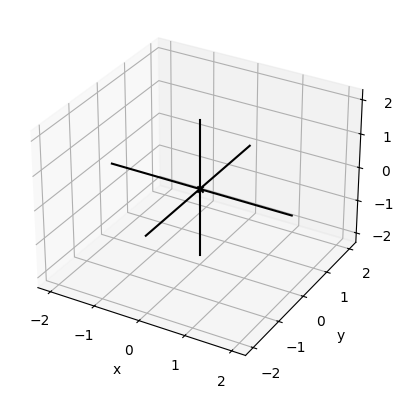

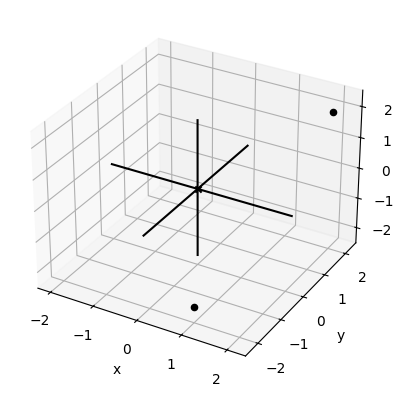

In [31]:
from draw3d import *

draw3d()
draw3d(Points3D((2, 2, 2), (1, -2, -2)))

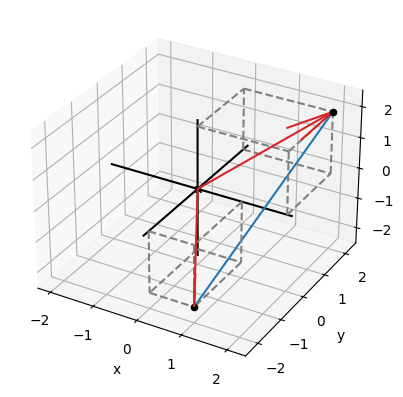

In [32]:
draw3d(
    Points3D((2, 2, 2), (1, -2, -2)),
    Arrow3D((2, 2, 2)),
    Arrow3D((1, -2, -2)),
    Segment3D((2, 2, 2), (1, -2, -2)),
    Box3D(2, 2, 2),
    Box3D(1, -2, -2),
)

In [33]:
def add(*vectors):
    return tuple(map(sum, zip(*vectors)))

In [34]:
from math import sqrt


def length(v):
    return sqrt(sum(cood**2 for cood in v))


length((3, 4, 12))

13.0

In [35]:
def dot(u, v):
    return sum(uc * vc for uc, vc in zip(u, v))

In [36]:
dot((1, 0), (0, 1))
dot((0, 3, 0), (0, 0, -5))

0

In [37]:
from math import acos, pi


def angle_between(u, v):
    return acos(dot(u, v) / (length(u) * length(v)))

In [38]:
angle_between((1, 2, 2), (2, 2, 1))

0.47588224966041665

In [39]:
def cross(u, v):
    ux, uy, uz = u
    vx, vy, vz = v
    return (uy * vz - uz * vy, uz * vx - ux * vz, ux * vy - uy * vx)

In [40]:
cross((1, 2, 2), (2, 2, 1))

(-2, 3, -2)

In [41]:
octahedron = [
    [(1, 0, 0), (0, 1, 0), (0, 0, 1)],
    [(1, 0, 0), (0, 0, -1), (0, 1, 0)],
    [(1, 0, 0), (0, 0, 1), (0, -1, 0)],
    [(1, 0, 0), (0, -1, 0), (0, 0, -1)],
    [(-1, 0, 0), (0, 0, 1), (0, 1, 0)],
    [(-1, 0, 0), (0, 1, 0), (0, 0, -1)],
    [(-1, 0, 0), (0, -1, 0), (0, 0, 1)],
    [(-1, 0, 0), (0, 0, -1), (0, -1, 0)],
]


In [42]:
def vertices(faces):
    return list({vertex for face in faces for vertex in face})

In [43]:
from math import cos, pi

int(cos(pi))

-1

In [44]:
def component(v, direction):
    return dot(v, direction) / length(direction)

In [45]:
def vector_to_2d(v):
    return (component(v, (1, 0, 0)), component(v, (0, 1, 0)))


def face_to_2d(face):
    return [vector_to_2d(vertex) for vertex in face]

In [46]:
def unit(v):
    from vectors import scale

    return scale(1.0 / length(v), v)

In [48]:
def normal(face):
    from vectors import subtract

    return cross(subtract(face[1], face[0]), subtract(face[2], face[0]))

In [ ]:
def render(faces, light = (1,2,3), color_map=matplotlib.colormaps['Blues'], lines='black'):
    from draw2d import draw2d, Polygon2D
    polygons = []
    for face in faces:
        unit_normal = unit(normal(face))
        if unit_normal[2] > 0:
            c = color_map(1 - dot(unit(normal(face)), unit(light)))
            p = Polygon2D(*face_to_2d(face), fill = c, color=lines)
            polygons.append(p)
    draw2d(*polygons, axes = False, origin = False, grid = None)

TypeError: Polygon.__init__() takes 2 positional arguments but 3 were given

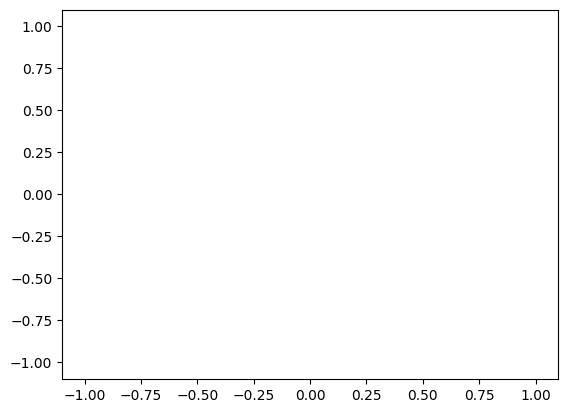

In [51]:
render(octahedron)